# EXIOBASE Sweden hotspot analysis

This notebook reproduces the hotspot analysis at **whole-Sweden level** rather than splitting Sweden into Stockholm and Rest of Sweden.

It keeps the same three dimensions as the original notebook:
- material extraction
- air emissions / GHG
- economic value / factor inputs

The consumption-based analysis uses the Sweden final-demand column(s) directly from EXIOBASE after `calc_all()` has been run.

In [1]:
import pymrio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import logging
import time

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
from IPython.display import display

In [2]:
# Path to EXIOBASE 3 zip file (adjust to your local setup).
EXIOBASE_PATH = Path("C:/EXIOBASE3/IOT_2024_pxp.zip")
if not EXIOBASE_PATH.exists():
    raise FileNotFoundError(f"EXIOBASE file not found: {EXIOBASE_PATH}")

# Output directory for results.
OUTPUT_DIR = Path("./results_sweden")
OUTPUT_DIR.mkdir(exist_ok=True)

# Sweden's EXIOBASE country code.
SWEDEN_CODE = "SE"

# Base year.
BASE_YEAR = 2024

In [3]:
def load_exiobase(path):
    """Load EXIOBASE 3 and compute x and A."""
    log.info(f"Loading EXIOBASE from {path} ...")
    t0 = time.time()

    exio = pymrio.parse_exiobase3(path=path)

    log.info(f"Parsed in {time.time() - t0:.1f}s. Computing x and A ...")
    exio.x = pymrio.calc_x(exio.Z, exio.Y)
    exio.A = pymrio.calc_A(exio.Z, exio.x)

    log.info(f"A matrix shape: {exio.A.shape}")
    log.info(f"Y matrix shape: {exio.Y.shape}")
    log.info(f"Regions: {len(exio.get_regions())}")
    log.info(f"Sectors per region: {len(exio.get_sectors())}")

    for ext_name in ["material", "air_emissions", "factor_inputs"]:
        ext = getattr(exio, ext_name, None)
        if ext is not None and ext.F is not None:
            log.info(f"Extension '{ext_name}': {ext.F.shape[0]} stressors")
        else:
            log.warning(f"Extension '{ext_name}': NOT FOUND")

    return exio


exio = load_exiobase(EXIOBASE_PATH)

2026-04-15 17:29:29,819 INFO Loading EXIOBASE from C:\EXIOBASE3\IOT_2024_pxp.zip ...
2026-04-15 17:29:29,852 INFO Read metadata from C:\EXIOBASE3\IOT_2024_pxp.zip
2026-04-15 17:29:29,855 INFO 20260415 17:29:29 - FILEIO -  Loaded IO system from C:\EXIOBASE3\IOT_2024_pxp.zip - 
2026-04-15 17:29:29,857 INFO Load data from Z.txt
2026-04-15 17:29:45,935 INFO Load data from Y.txt
2026-04-15 17:29:46,190 INFO Load data from x.txt
2026-04-15 17:29:46,204 INFO Load data from unit.txt
2026-04-15 17:29:46,223 INFO Load data from nutrients/F.txt
2026-04-15 17:29:46,373 INFO Load data from nutrients/F_Y.txt
2026-04-15 17:29:46,384 INFO Load data from nutrients/unit.txt
2026-04-15 17:29:46,387 INFO 20260415 17:29:46 - FILEIO -  Added satellite account from nutrients
2026-04-15 17:29:46,396 INFO Load data from water/F.txt
2026-04-15 17:29:46,680 INFO Load data from water/F_Y.txt
2026-04-15 17:29:46,692 INFO Load data from water/unit.txt
2026-04-15 17:29:46,696 INFO 20260415 17:29:46 - FILEIO -  Added

In [4]:
# =============================================================================
# Material rows -> Anthesis four primary categories
# =============================================================================

MATERIAL_CATEGORY_MAP = {
    "biomass": list(range(0, 23)),
    "fossil": list(range(23, 33)),
    "metals": list(range(33, 48)),
    "minerals": list(range(48, 62)),
    "recycled": [],
}


def aggregate_material_categories(F_material):
    """Aggregate the 62 EXIOBASE material rows into four Anthesis categories."""
    row_names = F_material.index.tolist()
    result = {}
    for category, row_indices in MATERIAL_CATEGORY_MAP.items():
        if not row_indices:
            continue
        selected_rows = [row_names[i] for i in row_indices]
        result[category] = F_material.loc[selected_rows].sum(axis=0)
    return pd.DataFrame(result).T


all_indices = []
for cat, indices in MATERIAL_CATEGORY_MAP.items():
    all_indices.extend(indices)
assert sorted(all_indices) == list(range(62)), "Material mapping does not cover all 62 rows"
assert len(all_indices) == len(set(all_indices)), "Material mapping has overlaps"
print("Material category mapping OK: 62 rows -> 4 categories")


# =============================================================================
# GHG emission rows -> aggregated GHG (CO2e)
# =============================================================================

GWP = {
    "CO2": 1,
    "CH4": 28,
    "N2O": 265,
    "SF6": 23500,
    "HFC": 1,
    "PFC": 1,
}

GHG_FOSSIL_ROWS = {
    "CO2": [
        "CO2 - combustion - air",
        "CO2 - non combustion - Cement production - air",
        "CO2 - non combustion - Lime production - air",
        "CO2 - waste - fossil - air",
    ],
    "CH4": [
        "CH4 - combustion - air",
        "CH4 - non combustion - Extraction/production of (natural) gas - air",
        "CH4 - non combustion - Extraction/production of crude oil - air",
        "CH4 - non combustion - Mining of antracite - air",
        "CH4 - non combustion - Mining of bituminous coal - air",
        "CH4 - non combustion - Mining of coking coal - air",
        "CH4 - non combustion - Mining of lignite (brown coal) - air",
        "CH4 - non combustion - Mining of sub-bituminous coal - air",
        "CH4 - non combustion - Oil refinery - air",
        "CH4 - agriculture - air",
        "CH4 - waste - air",
    ],
    "N2O": [
        "N2O - combustion - air",
        "N2O - agriculture - air",
    ],
    "SF6": ["SF6 - air"],
    "HFC": ["HFC - air"],
    "PFC": ["PFC - air"],
}

GHG_BIOGENIC_ROWS = [
    "CO2_bio - combustion - air",
    "CH4_bio - combustion - air",
    "N2O_bio - combustion - air",
    "CO2 - agriculture - peat decay - air",
    "CO2 - waste - biogenic - air",
]


def aggregate_ghg(F_air):
    """Aggregate air emission rows into fossil and biogenic GHG in kt CO2e."""
    all_rows = F_air.index.tolist()

    fossil_total = pd.Series(0.0, index=F_air.columns)
    for gas, rows in GHG_FOSSIL_ROWS.items():
        gwp = GWP[gas]
        for row_name in rows:
            if row_name in all_rows:
                fossil_total += F_air.loc[row_name] * gwp
            else:
                print(f"  WARNING: '{row_name}' not found in air_emissions index")

    bio_total = pd.Series(0.0, index=F_air.columns)
    for row_name in GHG_BIOGENIC_ROWS:
        if row_name in all_rows:
            if "CO2" in row_name:
                bio_total += F_air.loc[row_name] * 1
            elif "CH4" in row_name:
                bio_total += F_air.loc[row_name] * 28
            elif "N2O" in row_name:
                bio_total += F_air.loc[row_name] * 265

    fossil_total = fossil_total / 1e6
    bio_total = bio_total / 1e6

    return pd.DataFrame({
        "GHG_fossil_CO2e_kt": fossil_total,
        "GHG_biogenic_CO2e_kt": bio_total,
    }).T


air_rows = exio.air_emissions.F.index.tolist()
missing = []
for gas, rows in GHG_FOSSIL_ROWS.items():
    for r in rows:
        if r not in air_rows:
            missing.append(r)
for r in GHG_BIOGENIC_ROWS:
    if r not in air_rows:
        missing.append(r)

if missing:
    print(f"WARNING: {len(missing)} row(s) not found:")
    for m in missing:
        print(f"  {m}")
else:
    print("GHG row mapping OK: all specified rows found")

Material category mapping OK: 62 rows -> 4 categories
GHG row mapping OK: all specified rows found


In [5]:
# Compute all account matrices needed for production-based and consumption-based analysis.
# This is the step that enables D_pba and D_cba on the extension accounts.
log.info("Running calc_all() ...")
exio.calc_all()
log.info("calc_all() complete.")

2026-04-15 17:29:49,284 INFO Running calc_all() ...
2026-04-15 17:30:03,112 INFO 20260415 17:30:03 - MODIFICATION -  Leontief matrix L calculated
2026-04-15 17:30:03,112 INFO 20260415 17:30:03 - MODIFICATION -  Calculating accounts for extension nutrients
2026-04-15 17:30:13,584 INFO 20260415 17:30:13 - MODIFICATION -  Calculating accounts for extension water
2026-04-15 17:30:24,551 INFO 20260415 17:30:24 - MODIFICATION -  Calculating accounts for extension air_emissions
2026-04-15 17:30:36,449 INFO 20260415 17:30:36 - MODIFICATION -  Calculating accounts for extension land
2026-04-15 17:30:47,531 INFO 20260415 17:30:47 - MODIFICATION -  Calculating accounts for extension factor_inputs
2026-04-15 17:30:58,311 INFO 20260415 17:30:58 - MODIFICATION -  Calculating accounts for extension material
2026-04-15 17:31:09,806 INFO calc_all() complete.


In [6]:
def extract_sweden_results(exio):
    """Extract Sweden PBA and CBA accounts for the three dimensions."""
    results = {}

    # ------------------------------------------------------------------
    # 1) Material extraction
    # ------------------------------------------------------------------
    mat_ext = getattr(exio, "material", None)
    if mat_ext is not None and mat_ext.D_cba is not None:
        mat_pba_se = aggregate_material_categories(mat_ext.D_pba.loc[:, SWEDEN_CODE])
        mat_cba_se = aggregate_material_categories(mat_ext.D_cba.loc[:, SWEDEN_CODE])

        results["material"] = {
            "pba_se": mat_pba_se.sum(axis=1),
            "cba_se": mat_cba_se.sum(axis=1),
            "D_pba_se": mat_ext.D_pba.loc[:, SWEDEN_CODE],
            "D_cba_se": mat_ext.D_cba.loc[:, SWEDEN_CODE],
            "D_cba_full": mat_ext.D_cba,
            "D_pba_full": mat_ext.D_pba,
            "unit": "kt",
        }
        log.info("Extracted material results")
    else:
        log.warning("material extension D_cba not available")

    # ------------------------------------------------------------------
    # 2) Air emissions / GHG
    # ------------------------------------------------------------------
    air_ext = getattr(exio, "air_emissions", None)
    if air_ext is not None and air_ext.D_cba is not None:
        ghg_pba_se = aggregate_ghg(air_ext.D_pba.loc[:, SWEDEN_CODE])
        ghg_cba_se = aggregate_ghg(air_ext.D_cba.loc[:, SWEDEN_CODE])

        results["ghg"] = {
            "pba_se": ghg_pba_se.sum(axis=1),
            "cba_se": ghg_cba_se.sum(axis=1),
            "D_pba_se": air_ext.D_pba.loc[:, SWEDEN_CODE],
            "D_cba_se": air_ext.D_cba.loc[:, SWEDEN_CODE],
            "D_cba_full": air_ext.D_cba,
            "D_pba_full": air_ext.D_pba,
            "unit": "kt CO2e",
        }
        log.info("Extracted GHG results")
    else:
        log.warning("air_emissions extension D_cba not available")

    # ------------------------------------------------------------------
    # 3) Economic value / factor inputs
    # ------------------------------------------------------------------
    fi_ext = getattr(exio, "factor_inputs", None)
    if fi_ext is not None and fi_ext.D_cba is not None:
        results["factor_inputs"] = {
            "pba_se_total": fi_ext.D_pba.loc[:, SWEDEN_CODE].sum().sum(),
            "cba_se_total": fi_ext.D_cba.loc[:, SWEDEN_CODE].sum().sum(),
            "D_pba_se_by_sector": fi_ext.D_pba.loc[:, SWEDEN_CODE].sum(axis=0),
            "D_cba_full": fi_ext.D_cba,
            "D_pba_full": fi_ext.D_pba,
            "unit": "M.EUR",
        }
        log.info("Extracted factor_inputs results")
    else:
        log.warning("factor_inputs extension D_cba not available")

    return results


results = extract_sweden_results(exio)

2026-04-15 17:31:09,843 INFO Extracted material results
2026-04-15 17:31:09,862 INFO Extracted GHG results
2026-04-15 17:31:09,869 INFO Extracted factor_inputs results


In [7]:
def top_sectors(results, n=5):
    """Print the top Sweden sectors by PBA and CBA for the three dimensions."""
    print("=" * 70)
    print("TOP SECTORS — Sweden")
    print("=" * 70)
    print()

    top_results = {}

    # ------------------------------------------------------------------
    # Material extraction
    # ------------------------------------------------------------------
    if "material" in results:
        print("─" * 70)
        print("DIMENSION 1 — Material extraction (kt)")
        print("─" * 70)

        D_pba = results["material"]["D_pba_se"]
        D_cba = results["material"]["D_cba_se"]

        pba_by_sector = aggregate_material_categories(D_pba).sum(axis=0)
        cba_by_sector = aggregate_material_categories(D_cba).sum(axis=0)

        pba_top = pba_by_sector.sort_values(ascending=False).head(n)
        cba_top = cba_by_sector.sort_values(ascending=False).head(n)

        print(f"\n  Top {n} sectors by PBA (Swedish production hotspots):")
        print(f"  {'Rank':<5} {'Sector':<55} {'kt':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(pba_top.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        print(f"\n  Top {n} sectors by CBA (Swedish consumption hotspots):")
        print(f"  {'Rank':<5} {'Sector':<55} {'kt':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(cba_top.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        top_results["material"] = {"pba_top": pba_top, "cba_top": cba_top}

    # ------------------------------------------------------------------
    # GHG
    # ------------------------------------------------------------------
    if "ghg" in results:
        print("─" * 70)
        print("DIMENSION 2 — GHG emissions (kt CO2e)")
        print("─" * 70)

        D_pba = results["ghg"]["D_pba_se"]
        D_cba = results["ghg"]["D_cba_se"]

        pba_by_sector = aggregate_ghg(D_pba).sum(axis=0)
        cba_by_sector = aggregate_ghg(D_cba).sum(axis=0)

        pba_top = pba_by_sector.sort_values(ascending=False).head(n)
        cba_top = cba_by_sector.sort_values(ascending=False).head(n)

        print(f"\n  Top {n} sectors by PBA (Swedish production hotspots):")
        print(f"  {'Rank':<5} {'Sector':<55} {'kt CO2e':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(pba_top.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        print(f"\n  Top {n} sectors by CBA (Swedish consumption hotspots):")
        print(f"  {'Rank':<5} {'Sector':<55} {'kt CO2e':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(cba_top.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        top_results["ghg"] = {"pba_top": pba_top, "cba_top": cba_top}

    # ------------------------------------------------------------------
    # Factor inputs
    # ------------------------------------------------------------------
    if "factor_inputs" in results:
        print("─" * 70)
        print("DIMENSION 3 — Economic value: total factor inputs (M.EUR)")
        print("─" * 70)

        pba_by_sector = results["factor_inputs"]["D_pba_se_by_sector"]
        cba_by_sector = results["factor_inputs"]["D_cba_full"].loc[:, SWEDEN_CODE].sum(axis=0)

        pba_top = pba_by_sector.sort_values(ascending=False).head(n)
        cba_top = cba_by_sector.sort_values(ascending=False).head(n)

        print(f"\n  Top {n} sectors by PBA (Swedish production value hotspots):")
        print(f"  {'Rank':<5} {'Sector':<55} {'M.EUR':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(pba_top.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        print(f"\n  Top {n} sectors by CBA (Swedish consumption value hotspots):")
        print(f"  {'Rank':<5} {'Sector':<55} {'M.EUR':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(cba_top.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        top_results["factor_inputs"] = {"pba_top": pba_top, "cba_top": cba_top}

    return top_results


top = top_sectors(results, n=5)

TOP SECTORS — Sweden

──────────────────────────────────────────────────────────────────────
DIMENSION 1 — Material extraction (kt)
──────────────────────────────────────────────────────────────────────

  Top 5 sectors by PBA (Swedish production hotspots):
  Rank  Sector                                                          kt
  ----- ------------------------------------------------------- ----------
  1     Sand and clay                                            122,575.2
  2     Iron ores                                                 44,252.6
  3     Products of forestry, logging and related services (02)   42,530.3
  4     Copper ores and concentrates                              26,748.7
  5     Precious metal ores and concentrates                      10,459.6

  Top 5 sectors by CBA (Swedish consumption hotspots):
  Rank  Sector                                                          kt
  ----- ------------------------------------------------------- ----------
  1     Con

In [8]:
def top_source_country_sectors(results, n=10):
    """Print the top source country-sector pairs for Sweden CBA footprints."""
    def fmt_country(code):
        return code

    def fmt_pair(idx):
        return f"{fmt_country(idx[0])}: {idx[1][:38]}"

    print("=" * 70)
    print("TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint")
    print("=" * 70)

    cs = {}

    # ------------------------------------------------------------------
    # Material
    # ------------------------------------------------------------------
    if "material" in results:
        print("\nDIMENSION 1 — Material (kt)")
        fp_mat = results["material"]["D_cba_full"].loc[:, SWEDEN_CODE]
        fp_mat_agg = aggregate_material_categories(fp_mat)
        fp_mat_tot = fp_mat_agg.sum(axis=0)
        top_pairs = fp_mat_tot.sort_values(ascending=False).head(n)
        cs["material"] = {"top_pairs": top_pairs, "unit": "kt"}

        print(f"  {'Rank':<5} {'Country':<12} {'Sector':<45} {'kt':>10}")
        for rank, (idx, val) in enumerate(top_pairs.items(), 1):
            print(f"  {rank:<5} {fmt_country(idx[0]):<12} {idx[1][:45]:<45} {val:>10,.1f}")

    # ------------------------------------------------------------------
    # GHG
    # ------------------------------------------------------------------
    if "ghg" in results:
        print("\nDIMENSION 2 — GHG (kt CO2e)")
        fp_ghg = results["ghg"]["D_cba_full"].loc[:, SWEDEN_CODE]
        fp_ghg_agg = aggregate_ghg(fp_ghg)
        fp_ghg_tot = fp_ghg_agg.sum(axis=0)
        top_pairs = fp_ghg_tot.sort_values(ascending=False).head(n)
        cs["ghg"] = {"top_pairs": top_pairs, "unit": "kt CO2e"}

        print(f"  {'Rank':<5} {'Country':<12} {'Sector':<45} {'kt CO2e':>10}")
        for rank, (idx, val) in enumerate(top_pairs.items(), 1):
            print(f"  {rank:<5} {fmt_country(idx[0]):<12} {idx[1][:45]:<45} {val:>10,.1f}")

    # ------------------------------------------------------------------
    # Factor inputs
    # ------------------------------------------------------------------
    if "factor_inputs" in results:
        print("\nDIMENSION 3 — Economic value (M.EUR)")
        fp_fi = results["factor_inputs"]["D_cba_full"].loc[:, SWEDEN_CODE]
        fp_fi_tot = fp_fi.sum(axis=0)
        top_pairs = fp_fi_tot.sort_values(ascending=False).head(n)
        cs["factor_inputs"] = {"top_pairs": top_pairs, "unit": "M.EUR"}

        print(f"  {'Rank':<5} {'Country':<12} {'Sector':<45} {'M.EUR':>10}")
        for rank, (idx, val) in enumerate(top_pairs.items(), 1):
            print(f"  {rank:<5} {fmt_country(idx[0]):<12} {idx[1][:45]:<45} {val:>10,.1f}")

    return cs


cs = top_source_country_sectors(results, n=10)

TOP SOURCE COUNTRY-SECTORS — Sweden CBA footprint

DIMENSION 1 — Material (kt)
  Rank  Country      Sector                                                kt
  1     C            o                                               98,092.3
  2     P            r                                               23,100.6
  3     F            o                                               12,670.3
  4     P            r                                                7,352.3
  5     M            o                                                6,985.5
  6     H            o                                                6,954.9
  7     H            e                                                6,106.2
  8     P            u                                                5,803.3
  9     E            d                                                5,799.5
  10    M            a                                                5,591.6

DIMENSION 2 — GHG (kt CO2e)
  Rank  Country      Sector       

In [9]:
# Summary tables

summary = {}

if "material" in results:
    summary["material"] = pd.DataFrame({
        "PBA": results["material"]["pba_se"],
        "CBA": results["material"]["cba_se"],
    })
    summary["material"]["Net"] = summary["material"]["PBA"] - summary["material"]["CBA"]

if "ghg" in results:
    summary["ghg"] = pd.DataFrame({
        "PBA": results["ghg"]["pba_se"],
        "CBA": results["ghg"]["cba_se"],
    })
    summary["ghg"]["Net"] = summary["ghg"]["PBA"] - summary["ghg"]["CBA"]

if "factor_inputs" in results:
    summary["factor_inputs"] = pd.DataFrame({
        "value": [results["factor_inputs"]["pba_se_total"], results["factor_inputs"]["cba_se_total"]],
    }, index=["PBA", "CBA"])
    summary["factor_inputs"]["Net"] = np.nan

for dim, df in summary.items():
    print(f"\n{dim.upper()}")
    display(df)


MATERIAL


,PBA,CBA,Net
biomass,64371.562672,56723.595290,7647.967382
fossil,200.942609,23881.000873,-23680.058264
metals,85279.541394,33525.461551,51754.079843
minerals,128672.715597,160749.611544,-32076.895947



GHG


,PBA,CBA,Net
GHG_fossil_CO2e_kt,24926.888021,0.0,24926.888021
GHG_biogenic_CO2e_kt,427.943564,0.0,427.943564



FACTOR_INPUTS


,value,Net
PBA,561536.969934,NaN
CBA,537934.438686,NaN


In [10]:
# Sanity checks and compact workshop-style printout

print("=" * 70)
print("WORKSHOP SUMMARY: Sweden results")
print("=" * 70)
print(f"Base year : {BASE_YEAR}")
print()

if "material" in results:
    print("─" * 70)
    print("DIMENSION 1 — Material extraction (kt)")
    print("─" * 70)
    print(f"  {'Category':>12}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
    print(f"  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*13}")
    for cat in results["material"]["pba_se"].index:
        pba = results["material"]["pba_se"][cat]
        cba = results["material"]["cba_se"][cat]
        net = pba - cba
        direction = "net exporter" if net > 0 else "NET IMPORTER"
        print(f"  {cat:>12}  {pba:>12,.1f}  {cba:>12,.1f}  {net:>12,.1f}  {direction}")
    print()

if "ghg" in results:
    print("─" * 70)
    print("DIMENSION 2 — GHG emissions (kt CO2e)")
    print("─" * 70)
    print(f"  {'Category':>22}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
    print(f"  {'-'*22}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*13}")
    for cat in results["ghg"]["pba_se"].index:
        pba = results["ghg"]["pba_se"][cat]
        cba = results["ghg"]["cba_se"][cat]
        net = pba - cba
        direction = "net exporter" if net > 0 else "NET IMPORTER"
        print(f"  {cat:>22}  {pba:>12,.1f}  {cba:>12,.1f}  {net:>12,.1f}  {direction}")
    print()

if "factor_inputs" in results:
    print("─" * 70)
    print("DIMENSION 3 — Economic value: total factor inputs (M.EUR)")
    print("─" * 70)
    pba_total = results["factor_inputs"]["pba_se_total"]
    cba_total = results["factor_inputs"]["cba_se_total"]
    print(f"  PBA (Swedish production value) : {pba_total:>12,.1f} M.EUR")
    print(f"  CBA (Swedish consumption value): {cba_total:>12,.1f} M.EUR")
    print(f"  Net (PBA - CBA)                : {pba_total - cba_total:>12,.1f} M.EUR")
    print()

WORKSHOP SUMMARY: Sweden results
Base year : 2024

──────────────────────────────────────────────────────────────────────
DIMENSION 1 — Material extraction (kt)
──────────────────────────────────────────────────────────────────────
      Category           PBA           CBA           Net  Direction
  ------------  ------------  ------------  ------------  -------------
       biomass      64,371.6      56,723.6       7,648.0  net exporter
        fossil         200.9      23,881.0     -23,680.1  NET IMPORTER
        metals      85,279.5      33,525.5      51,754.1  net exporter
      minerals     128,672.7     160,749.6     -32,076.9  NET IMPORTER

──────────────────────────────────────────────────────────────────────
DIMENSION 2 — GHG emissions (kt CO2e)
──────────────────────────────────────────────────────────────────────
                Category           PBA           CBA           Net  Direction
  ----------------------  ------------  ------------  ------------  -------------
   

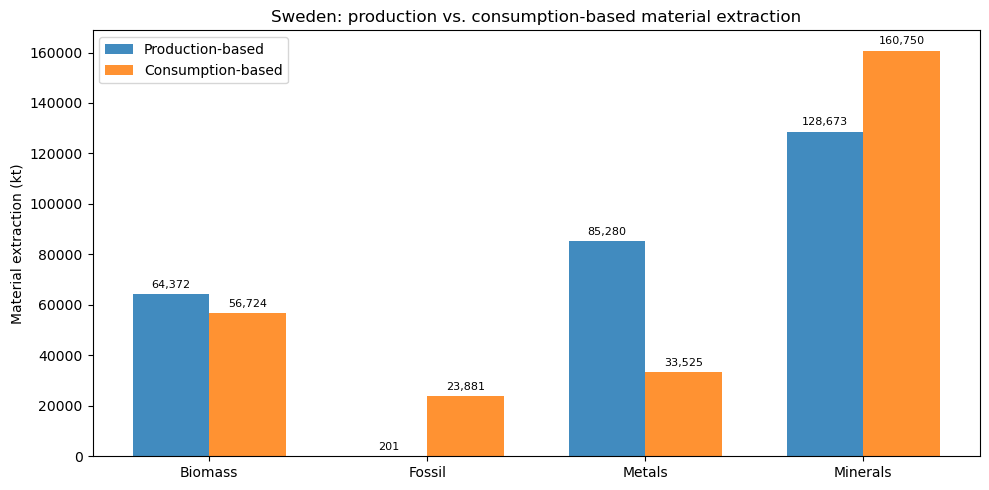

2026-04-15 17:31:10,936 INFO Saved plot: sweden_material_comparison.png


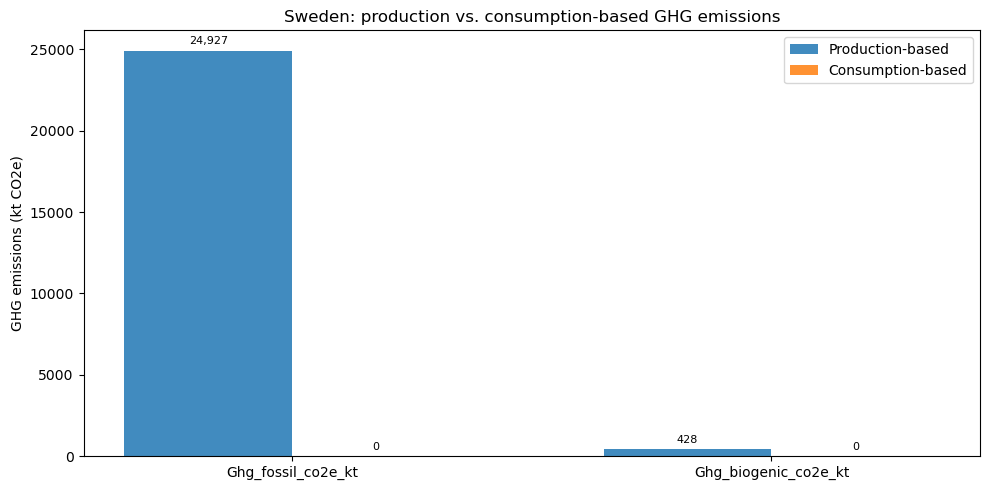

2026-04-15 17:31:11,449 INFO Saved plot: sweden_ghg_comparison.png


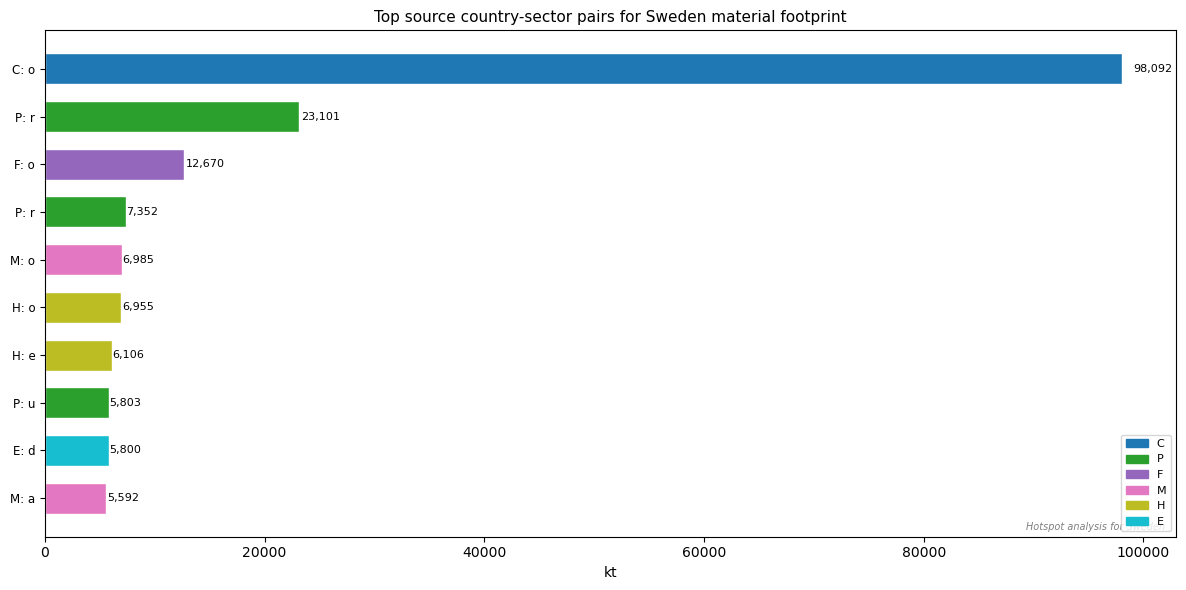

2026-04-15 17:31:11,781 INFO sweden_material_source_country_sectors.png saved


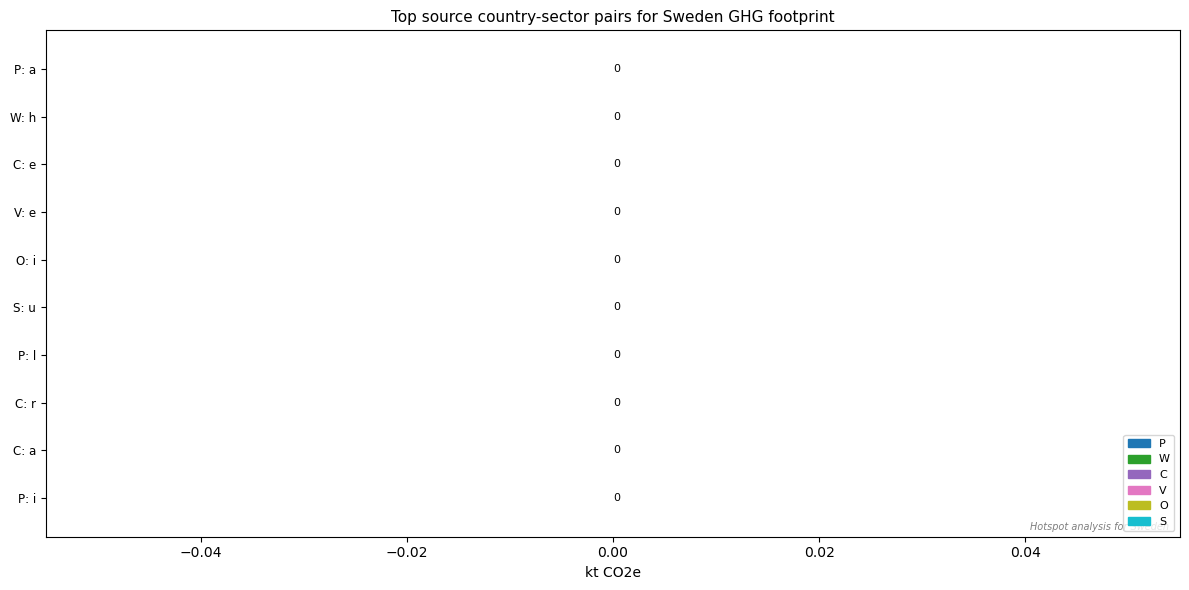

2026-04-15 17:31:12,094 INFO sweden_ghg_source_country_sectors.png saved


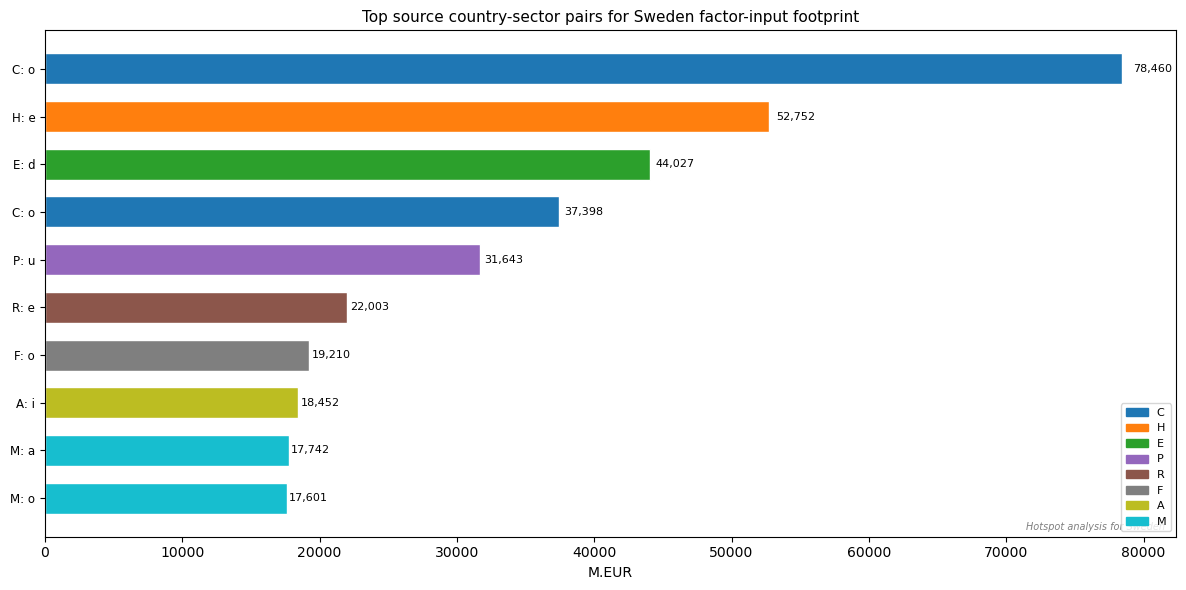

2026-04-15 17:31:12,397 INFO sweden_factor_inputs_source_country_sectors.png saved


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CAT_COLORS = {
    "biomass":  "#55A868",
    "fossil":   "#C44E52",
    "metals":   "#8172B2",
    "minerals": "#937860",
}

def fmt_country(code):
    return code

def fmt_pair(idx):
    return f"{fmt_country(idx[0])}: {idx[1][:38]}"

def add_note(ax, note="Hotspot analysis for Sweden"):
    ax.text(
        0.99, 0.01, note, transform=ax.transAxes,
        fontsize=7, color='grey', ha='right', va='bottom', style='italic'
    )

def country_sector_chart(top_pairs, xlabel, title, filename):
    labels = [fmt_pair(idx) for idx in top_pairs.index]
    vals = top_pairs.values
    unique_countries = list(dict.fromkeys(idx[0] for idx in top_pairs.index))
    cmap = plt.colormaps.get_cmap('tab10').resampled(max(len(unique_countries), 1))
    c_map = {c: cmap(i) for i, c in enumerate(unique_countries)}
    colors = [c_map[idx[0]] for idx in top_pairs.index]

    fig, ax = plt.subplots(figsize=(12, 6))
    y = np.arange(len(labels))
    ax.barh(y, vals, color=colors, edgecolor='white', height=0.65)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11)

    patches = [mpatches.Patch(color=c_map[c], label=fmt_country(c))
               for c in unique_countries]
    ax.legend(handles=patches, loc='lower right', fontsize=8)

    for i, v in enumerate(vals):
        ax.text(v * 1.01 if v >= 0 else v * 0.99, i, f'{v:,.0f}', va='center', fontsize=8)

    add_note(ax)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f"{filename} saved")


def plot_pba_vs_cba(data, title, ylabel, filename):
    categories = data['pba_se'].index.tolist()
    pba = data['pba_se'].values
    cba = data['cba_se'].values

    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, pba, width, label='Production-based', alpha=0.85)
    bars2 = ax.bar(x + width/2, cba, width, label='Consumption-based', alpha=0.85)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in categories])
    ax.legend()

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.annotate(f'{h:,.0f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f"Saved plot: {filename}")


if 'material' in results:
    plot_pba_vs_cba(
        results['material'],
        "Sweden: production vs. consumption-based material extraction",
        "Material extraction (kt)",
        "sweden_material_comparison.png"
    )

if 'ghg' in results:
    plot_pba_vs_cba(
        results['ghg'],
        "Sweden: production vs. consumption-based GHG emissions",
        "GHG emissions (kt CO2e)",
        "sweden_ghg_comparison.png"
    )

if "material" in cs:
    country_sector_chart(
        cs["material"]["top_pairs"],
        "kt",
        "Top source country-sector pairs for Sweden material footprint",
        "sweden_material_source_country_sectors.png"
    )

if "ghg" in cs:
    country_sector_chart(
        cs["ghg"]["top_pairs"],
        "kt CO2e",
        "Top source country-sector pairs for Sweden GHG footprint",
        "sweden_ghg_source_country_sectors.png"
    )

if "factor_inputs" in cs:
    country_sector_chart(
        cs["factor_inputs"]["top_pairs"],
        "M.EUR",
        "Top source country-sector pairs for Sweden factor-input footprint",
        "sweden_factor_inputs_source_country_sectors.png"
    )

In [12]:
# Save compact CSV outputs

log.info("Saving CSV outputs ...")

for dim, data in top.items():
    unit = results[dim]["unit"]
    data["pba_top"].to_frame(f"PBA_Sweden_{unit}").to_csv(OUTPUT_DIR / f"top_sectors_PBA_{dim}.csv")
    data["cba_top"].to_frame(f"CBA_Sweden_{unit}").to_csv(OUTPUT_DIR / f"top_sectors_CBA_{dim}.csv")

for dim, data in cs.items():
    unit = data["unit"]
    data["top_pairs"].to_frame(f"CBA_top_sectors_{unit}").to_csv(OUTPUT_DIR / f"top_country_sectors_CBA_{dim}.csv")

for dim, df in summary.items():
    df.to_csv(OUTPUT_DIR / f"summary_{dim}.csv")

log.info(f"All outputs written to: {OUTPUT_DIR}")
print(f"Outputs written to: {OUTPUT_DIR.resolve()}")

2026-04-15 17:31:12,408 INFO Saving CSV outputs ...
2026-04-15 17:31:12,431 INFO All outputs written to: results_sweden


Outputs written to: C:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\results_sweden
